In [1]:
import pandas as pd 
import numpy as np 
import statsmodels.formula.api as smf 
from copy import deepcopy 
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
import json

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 
import seaborn as sns 
from IPython.display import display

import importlib
import pgg_helper as pgg 


import warnings
warnings.filterwarnings("ignore")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [3]:
md_learn = pgg.preprocess.master_data("../data/raw_data/learning_wave", 
                                      "../data/exp_config_files/learning.csv")

md_val = pgg.preprocess.master_data("../data/raw_data/validation_wave/", 
                                      "../data/exp_config_files/validation.csv")

In [4]:
processed_data_dir = "../data/processed_data/"
df_paired_val = pd.read_csv(processed_data_dir + "df_paired_val.csv")
df_paired_learn = pd.read_csv(processed_data_dir + "df_paired_learn.csv")
df_analysis_val = pd.read_csv(processed_data_dir + "df_analysis_val.csv")
df_analysis_learn = pd.read_csv(processed_data_dir + "df_analysis_learn.csv")
df_rounds_learn = pd.read_csv(processed_data_dir + "df_rounds_learn.csv")
df_rounds_val = pd.read_csv(processed_data_dir + "df_rounds_val.csv")
df_predictions = pd.read_csv(processed_data_dir + "prediction_survey.csv").query("prediction.between(-0.2,1.2)")
df_learning_config = pd.read_csv("../data/exp_config_files/learning.csv")
df_validation_config = pd.read_csv("../data/exp_config_files/validation.csv")

df_rounds_learn = df_rounds_learn.merge(df_analysis_learn, on="gameId", how="left").query("valid_number_of_starting_players == True").dropna(subset=["data.roundPayoff"]).reset_index(drop=True)
df_rounds_val = df_rounds_val.merge(df_analysis_val, on="gameId", how="left").query("valid_number_of_starting_players == True").dropna(subset=["data.roundPayoff"]).reset_index(drop=True)

# Section S1. 

## Table 1. Intended, collected, and retained trial by configuration in the validation wave 

In [5]:
df_validation_condition_counts = df_analysis_val.groupby("name").agg({"valid_number_of_starting_players":["size", "sum", lambda x: sum(~x)]}).reset_index()
df_validation_condition_counts.columns = ["name", "sampled", "retained", "rejected"]
df_validation_condition_counts["configId"] = [int(x.split("_")[1])+1 for x in df_validation_condition_counts["name"]]
df_validation_condition_counts["arm"] = [{"C":"Control", "T":"Treatment"}[x.split("_")[2]] for x in df_validation_condition_counts["name"]]
df_validation_condition_counts["intended"] = 12

assert((df_validation_condition_counts["retained"] + df_validation_condition_counts["rejected"]).equals(df_validation_condition_counts["sampled"]))
assert(len(df_validation_condition_counts) == 40)

df_validation_condition_counts[["configId", "arm", "intended", "sampled", "retained"]].sort_values(["configId", "arm"])

,configId,arm,intended,sampled,retained
0,1,Control,12,12,10
1,1,Treatment,12,12,12
22,2,Control,12,12,8
23,2,Treatment,12,12,8
24,3,Control,12,12,9
25,3,Treatment,12,12,11
26,4,Control,12,10,9
27,4,Treatment,12,11,10
28,5,Control,12,12,12
29,5,Treatment,12,10,9


# Section S2.

## S2.2. Data cleansing and filtration

In [15]:
# Technical filter: 

print("Games excluded for technical reasons in learning wave")
for gameId in md_learn.df_games[md_learn.df_games["data.totalPayoff"].isnull()]["_id"]:
    print(gameId)
    
print("Games excluded for technical reasons in validation wave")
for gameId in md_val.df_games[md_val.df_games["data.totalPayoff"].isnull()]["_id"]:
    print(gameId)


Games excluded for technical reasons in learning wave
SbpdWekiRC9XrEeXW
XT4BGco72Tioegwe7
dwPjmfg4QLEFT9yXf
Games excluded for technical reasons in validation wave
ByNgdtp6pK2zYNx7D
ZPjkeokvYuH5YoC7h
DAN4EmCeEvdBditaF


In [17]:
# Content filter: 

df_analysis_learn_unfiltered = pgg.preprocess.generate_df_analysis(
                                   df_players = md_learn.df_players, 
                                   df_rounds = md_learn.df_rounds, 
                                   df_games = md_learn.df_games, 
                                   df_treatments = md_learn.df_treatments, 
                                   df_treatment_config = md_learn.df_treatment_config, 
                                   PAIRED_MATCH_PLAYER_DIFF_PCT=pgg.constants.PAIRED_MATCH_PLAYER_DIFF_PCT, 
                                                        REL_EFF_SMOOTHING_FACTOR=pgg.constants.REL_EFF_SMOOTHING_FACTOR,
                                            is_validation=False, filtered=False)

df_analysis_val_unfiltered = pgg.preprocess.generate_df_analysis(
                                   df_players = md_val.df_players, 
                                   df_rounds = md_val.df_rounds, 
                                   df_games = md_val.df_games, 
                                   df_treatments = md_val.df_treatments, 
                                   df_treatment_config = md_val.df_treatment_config, 
                                   PAIRED_MATCH_PLAYER_DIFF_PCT=pgg.constants.PAIRED_MATCH_PLAYER_DIFF_PCT, 
                                                        REL_EFF_SMOOTHING_FACTOR=pgg.constants.REL_EFF_SMOOTHING_FACTOR,
                                          is_validation=True, filtered=False)


print("Game IDs excluded from learning set (other than server failures)")
print("\nExclusion: A total of 7 games had a multiplier of 1 (but one failed mid-way), and 1 game had a reward cycle.")
display(set(df_analysis_learn_unfiltered["gameId"]).difference(set(df_analysis_learn["gameId"])))

print("Game IDs excluded from validation set (other than server failures)")
display(set(df_analysis_val_unfiltered["gameId"]).difference(set(df_analysis_val["gameId"])))


set_excluded_learning_gameids = set(df_analysis_learn_unfiltered["gameId"]).difference(set(df_analysis_learn["gameId"]))




Game IDs excluded from learning set (other than server failures)

Exclusion: A total of 7 games had a multiplier of 1 (but one failed mid-way), and 1 game had a reward cycle.


{'QkNKFYHokbndpGhph',
 'XCabBPXLcM9Ev7ssq',
 'XT4BGco72Tioegwe7',
 'dTNQ5xKrAQxPyhdTx',
 'g2Qk3YD7xPASgkwki',
 'k2vfubE2hWC33SD5B',
 'oEkrWYrRhfFTo4uNJ',
 'zQnZ9X9zHXbheAcTT'}

Game IDs excluded from validation set (other than server failures)


set()

In [21]:
# Recruitment filter 
print("Games excluded in learning wave for insufficient recruitment")
display(df_analysis_learn["valid_number_of_starting_players"].value_counts())

print("\nGames excluded in validation wave for insufficient recruitment")
display(df_analysis_val["valid_number_of_starting_players"].value_counts())

Games excluded in learning wave for insufficient recruitment


valid_number_of_starting_players
True     335
False     31
Name: count, dtype: int64


Games excluded in validation wave for insufficient recruitment


valid_number_of_starting_players
True     417
False     53
Name: count, dtype: int64

In [8]:
# Recruitment filter 
print("Games excluded in learning wave for insufficient recruitment")
display(df_analysis_learn["valid_number_of_starting_players"].value_counts())

print("\nGames excluded in validation wave for insufficient recruitment")
display(df_analysis_val["valid_number_of_starting_players"].value_counts())

Games excluded in learning wave for insufficient recruitment


valid_number_of_starting_players
True     335
False     31
Name: count, dtype: int64


Games excluded in validation wave for insufficient recruitment


valid_number_of_starting_players
True     417
False     53
Name: count, dtype: int64

# Section S3. Robustness check: Interpretation of the participant dropout exclusion criterion 

In [5]:
def temp_generate_df_paired(df_analysis, is_validation):
    query_condition = "prereg_flag" if is_validation else "prereg_flag and paired_config"
    
    temp_df_treatment = (df_analysis.drop(columns="CONFIG_MPCR_adjusted").query(query_condition)
                         .query("CONFIG_punishmentExists")
                         .groupby("CONFIG_configId")[["itt_efficiency", "itt_relative_efficiency"]]
                         .mean().reset_index()
                         .rename(columns={"itt_efficiency":"treatment_itt_efficiency", "itt_relative_efficiency":"treatment_itt_relative_efficiency"}))

    temp_df_control = (df_analysis.drop(columns="CONFIG_MPCR_adjusted").query(query_condition)
                         .query("~CONFIG_punishmentExists")
                         .groupby("CONFIG_configId")[["itt_efficiency", "itt_relative_efficiency"]]
                         .mean().reset_index()
                         .rename(columns={"itt_efficiency":"control_itt_efficiency", "itt_relative_efficiency":"control_itt_relative_efficiency"}))

    df_prediction = (df_analysis.drop(columns="CONFIG_MPCR_adjusted").query(query_condition)
                    .filter(like="CONFIG").drop(columns=["CONFIG_punishmentExists", "CONFIG_treatmentName"]).drop_duplicates()
                    .merge(temp_df_treatment, on="CONFIG_configId", how="left")
                    .merge(temp_df_control, on="CONFIG_configId", how="left")
                    .dropna(subset=["treatment_itt_efficiency","treatment_itt_relative_efficiency", "control_itt_efficiency", "control_itt_relative_efficiency"])
                    .reset_index(drop=True))

    df_prediction["treatment_effect"] = df_prediction["treatment_itt_relative_efficiency"] - df_prediction["control_itt_relative_efficiency"]
    df_prediction["positive_treatment_effect"] = (df_prediction["treatment_effect"] >= 0).astype(int)

    assert len(df_prediction) == df_prediction["CONFIG_configId"].nunique()

    return df_prediction

In [6]:
# Add pre-reg flag for the alternative exlcusion criterion to the learning wave data 
df_learn_last_round = md_learn.df_rounds.groupby(["gameId", "round_index"])["data.roundPayoff"].agg(lambda x: (~x.isnull()).sum()).reset_index().drop_duplicates(subset=["gameId"], keep="last")
dict_learn_last_round = dict(zip(df_learn_last_round["gameId"], df_learn_last_round["data.roundPayoff"]))

df_analysis_learn["num_players_final_round"] = df_analysis_learn["gameId"].map(dict_learn_last_round)
df_analysis_learn["intended_minus_final"] = df_analysis_learn["CONFIG_playerCount"] - df_analysis_learn["num_players_final_round"]
df_analysis_learn["prereg_flag"] = ( df_analysis_learn["intended_minus_final"] / df_analysis_learn["CONFIG_playerCount"]) <= 0.18

# Add pre-reg flag for the alternative exlcusion criterion to the validation wave data 
df_val_last_round = md_val.df_rounds.groupby(["gameId", "round_index"])["data.roundPayoff"].agg(lambda x: (~x.isnull()).sum()).reset_index().drop_duplicates(subset=["gameId"], keep="last")
dict_val_last_round = dict(zip(df_val_last_round["gameId"], df_val_last_round["data.roundPayoff"]))

df_analysis_val["num_players_final_round"] = df_analysis_val["gameId"].map(dict_val_last_round)
df_analysis_val["intended_minus_final"] = df_analysis_val["CONFIG_playerCount"] - df_analysis_val["num_players_final_round"]
df_analysis_val["prereg_flag"] = ( df_analysis_val["intended_minus_final"] / df_analysis_val["CONFIG_playerCount"]) <= 0.18

# Create paired dataset based on alternative criterion 
df_paired_learn_filter_check = temp_generate_df_paired(df_analysis_learn, False)
df_paired_val_filter_check = temp_generate_df_paired(df_analysis_val, True)


In [45]:
# Number of games
print(df_analysis_learn.query("valid_number_of_starting_players").shape, df_analysis_learn.query("prereg_flag").shape)
print(df_analysis_val.query("valid_number_of_starting_players").shape, df_analysis_val.query("prereg_flag").shape)

# Paired conditions 
print(df_paired_learn.shape, df_paired_learn_filter_check.shape)

(335, 66) (318, 66)
(417, 65) (382, 65)
(150, 32) (136, 32)


In [49]:
# Contribution stats 
print("Contributions in the learning wave:")
print(md_learn.df_rounds.merge(df_analysis_learn.filter(regex="gameId|CONFIG_|prereg_flag"), on="gameId", how="left").query("prereg_flag == True").groupby("CONFIG_punishmentExists")["data.contribution"].mean() / 20, "\n")

print("Contributions in the validation wave:")
print(md_val.df_rounds.merge(df_analysis_val.filter(regex="gameId|CONFIG_|prereg_flag"), on="gameId", how="left").query("prereg_flag == True").groupby("CONFIG_punishmentExists")["data.contribution"].mean() / 20)

Contributions in the learning wave:
CONFIG_punishmentExists
False    0.725934
True     0.804332
Name: data.contribution, dtype: float64 

Contributions in the validation wave:
CONFIG_punishmentExists
False    0.732446
True     0.817426
Name: data.contribution, dtype: float64


In [52]:
# Normalized efficiency stats 
print("Normalized efficiency in the learning wave:")
print(df_analysis_learn.query("prereg_flag").groupby("CONFIG_punishmentExists")["itt_relative_efficiency"].mean(), "\n")

print("Normalized efficiency in the validation wave:")
print(df_analysis_val.query("prereg_flag").groupby("CONFIG_punishmentExists")["itt_relative_efficiency"].mean())

Normalized efficiency in the learning wave:
CONFIG_punishmentExists
False    0.713156
True     0.629620
Name: itt_relative_efficiency, dtype: float64 

Normalized efficiency in the validation wave:
CONFIG_punishmentExists
False    0.718444
True     0.671733
Name: itt_relative_efficiency, dtype: float64


In [55]:
# Check heterogeneity stats in the learning wave 

CLUSTER_COLUMNS = ['CONFIG_playerCount', 'CONFIG_numRounds', 'CONFIG_showNRounds', 
                   'CONFIG_MPCR', 'CONFIG_allOrNothing', 'CONFIG_chat', 'CONFIG_defaultContribProp', 
                   'CONFIG_rewardExists', 'CONFIG_showOtherSummaries', "CONFIG_punishmentCost", "CONFIG_punishmentTech",
                   'CONFIG_showPunishmentId']

df_analysis_learn_kmeans = deepcopy(df_analysis_learn)
df_analysis_learn_kmeans.loc[:,["CONFIG_playerCount", "CONFIG_numRounds", "CONFIG_punishmentCost", "CONFIG_punishmentTech"]] = MinMaxScaler().fit_transform(df_analysis_learn_kmeans.loc[:,["CONFIG_playerCount", "CONFIG_numRounds", "CONFIG_punishmentCost", "CONFIG_punishmentTech"]])

kmeans = KMeans(n_clusters=20, random_state=2024)
df_analysis_learn_kmeans["cluster"] = kmeans.fit_predict(df_analysis_learn_kmeans[CLUSTER_COLUMNS])
df_cluster_estimates = df_analysis_learn_kmeans.query("prereg_flag").groupby("cluster").apply(lambda x: smf.ols("itt_relative_efficiency ~ CONFIG_punishmentExists", data=x).fit()).reset_index().rename(columns={0:"ols_model"})
df_cluster_estimates["treatment_effect_mean"] = df_cluster_estimates["ols_model"].apply(lambda x: x.params["CONFIG_punishmentExists[T.True]"])
df_cluster_estimates["treatment_effect_se"] = df_cluster_estimates["ols_model"].apply(lambda x: x.bse["CONFIG_punishmentExists[T.True]"])

pgg.analysis.calc_q_i2(df_cluster_estimates[["treatment_effect_mean", "treatment_effect_se"]])

{'Q': 29.35, 'Q_pval': 0.061, 'Q_dof': 19, 'i2': 0.35}

In [57]:
# Check heterogeneity stats in the validation wave 

df_paired_val_filter_check["ols_model"] = df_paired_val_filter_check["CONFIG_configId"].map(df_analysis_val.query("prereg_flag").groupby("CONFIG_configId").apply(lambda x: smf.ols("itt_relative_efficiency ~ CONFIG_punishmentExists", data=x).fit()))
df_paired_val_filter_check["treatment_effect"] = df_paired_val_filter_check["treatment_itt_efficiency"] - df_paired_val_filter_check["control_itt_efficiency"]
df_paired_val_filter_check["treatment_effect_mean"] = df_paired_val_filter_check["ols_model"].apply(lambda x: x.params["CONFIG_punishmentExists[T.True]"])
df_paired_val_filter_check["treatment_effect_se"] = df_paired_val_filter_check["ols_model"].apply(lambda x: x.bse["CONFIG_punishmentExists[T.True]"])

pgg.analysis.calc_q_i2(df_paired_val_filter_check[["treatment_effect_mean", "treatment_effect_se"]])

{'Q': 32.99, 'Q_pval': 0.024, 'Q_dof': 19, 'i2': 0.42}

In [13]:
# Fit models and check OOS predictive power 
print("RF HPO...")
hpo_rf = pgg.analysis.skopt_param_optimization_kfold("RF", n_calls=50, 
                          df_paired=df_paired_learn_filter_check, 
                          feature_cols=pgg.constants.PREDICTION_FEATURE_COLS, 
                          outcome_col="treatment_itt_efficiency",
                                                   n_folds=10, scaled=False, interactions=False, random_seed=2023, metric="mse")
print("XGB HPO...")
hpo_xgb = pgg.analysis.skopt_param_optimization_kfold("XGB", n_calls=50, 
                          df_paired=df_paired_learn_filter_check, 
                          feature_cols=pgg.constants.PREDICTION_FEATURE_COLS, 
                          outcome_col="treatment_itt_efficiency",
                                                   n_folds=10, scaled=False, interactions=False, random_seed=2023, metric="mse")

print("MLP HPO...")
hpo_mlp = pgg.analysis.skopt_param_optimization_kfold("KERAS_MLP", n_calls=50, 
                          df_paired=df_paired_learn_filter_check, 
                          feature_cols=pgg.constants.PREDICTION_FEATURE_COLS, 
                          outcome_col="treatment_itt_efficiency",
                                                   n_folds=10, scaled=True, interactions=False, random_seed=2023, metric="mse")
print("ENet HPO...")
hpo_elastic = pgg.analysis.skopt_param_optimization_kfold("ELASTICNET", n_calls=50, 
                          df_paired=df_paired_learn_filter_check, 
                          feature_cols=pgg.constants.PREDICTION_FEATURE_COLS, 
                          outcome_col="treatment_itt_efficiency",
                                                   n_folds=10, scaled=True, interactions=True, random_seed=2023, metric="mse", n_jobs=1)

json.dump(obj={"RF":hpo_rf, "XGB":hpo_xgb, "MLP":hpo_mlp, "ELASTIC":hpo_elastic},
          fp=open("../data/robustness_check_hpo_model_configs.json", "w"), default=int)

RF HPO...
XGB HPO...
MLP HPO...


ENet HPO...


In [28]:
fitted_models_filter_check = pgg.get_models(hpo_json_filepath="../data/robustness_check_hpo_model_configs.json",
                                           df_paired_learn=df_paired_learn_filter_check,
                                           feature_cols=pgg.constants.PREDICTION_FEATURE_COLS,
                                           target_col="treatment_itt_efficiency",
                                           fitted=True)

# Get predictions 
df_paired_val_filter_check["ols_filter_check_pred"] = fitted_models_filter_check["ols"].predict(df_paired_val_filter_check[pgg.constants.PREDICTION_FEATURE_COLS])
df_paired_val_filter_check["rf_filter_check_pred"] = fitted_models_filter_check["rf"].predict(df_paired_val_filter_check[pgg.constants.PREDICTION_FEATURE_COLS])
df_paired_val_filter_check["xgb_filter_check_pred"] = fitted_models_filter_check["xgb"].predict(df_paired_val_filter_check[pgg.constants.PREDICTION_FEATURE_COLS])
df_paired_val_filter_check["mlp_filter_check_pred"] = fitted_models_filter_check["mlp"].predict(df_paired_val_filter_check[pgg.constants.PREDICTION_FEATURE_COLS])
df_paired_val_filter_check["elastic_filter_check_pred"] = fitted_models_filter_check["enet"].predict(df_paired_val_filter_check[pgg.constants.PREDICTION_FEATURE_COLS])

In [29]:
# Print predictive performance
for model in ["elastic", "ols", "rf", "xgb", "mlp"]:
    implemented_rmse = np.sqrt(mean_squared_error(df_paired_val["treatment_itt_efficiency"]*100, df_paired_val[f"{model}_prereg_pred"]*100))
    filter_check_rmse = np.sqrt(mean_squared_error(df_paired_val_filter_check["treatment_itt_efficiency"]*100, df_paired_val_filter_check[f"{model}_filter_check_pred"]*100))
    
    print(f"{model}: Implemented: {implemented_rmse.round(2)} -- Filter check: {filter_check_rmse.round(2)}")

elastic: Implemented: 4.52 -- Filter check: 4.66
ols: Implemented: 5.22 -- Filter check: 5.72
rf: Implemented: 5.4 -- Filter check: 5.29
xgb: Implemented: 6.33 -- Filter check: 6.21
mlp: Implemented: 5.79 -- Filter check: 8.48


# Section S7. Estimating the average effect of punishment on contributions and normalized efficiency
(See accompanying RMarkdown notebook)

# Section S8. Detecting and measuring heterogeneity in the effect of punishment

## Table S5. Data points and punishment effect estimates within each learning wave cluster

In [14]:
# Heterogeneity in clustered learning wave experiments 
CLUSTER_COLUMNS = ['CONFIG_playerCount', 'CONFIG_numRounds', 'CONFIG_showNRounds', 
                   'CONFIG_MPCR', 'CONFIG_allOrNothing', 'CONFIG_chat', 'CONFIG_defaultContribProp', 
                   'CONFIG_rewardExists', 'CONFIG_showOtherSummaries', "CONFIG_punishmentCost", "CONFIG_punishmentTech",
                   'CONFIG_showPunishmentId']

df_analysis_learn_kmeans = deepcopy(df_analysis_learn)
df_analysis_learn_kmeans.loc[:,["CONFIG_playerCount", "CONFIG_numRounds", "CONFIG_punishmentCost", "CONFIG_punishmentTech"]] = MinMaxScaler().fit_transform(df_analysis_learn_kmeans.loc[:,["CONFIG_playerCount", "CONFIG_numRounds", "CONFIG_punishmentCost", "CONFIG_punishmentTech"]])

kmeans = KMeans(n_clusters=20, random_state=2024)
df_analysis_learn_kmeans["cluster"] = kmeans.fit_predict(df_analysis_learn_kmeans[CLUSTER_COLUMNS])
df_cluster_estimates = df_analysis_learn_kmeans.query("valid_number_of_starting_players").groupby("cluster").apply(lambda x: smf.ols("itt_relative_efficiency ~ CONFIG_punishmentExists", data=x).fit()).reset_index().rename(columns={0:"ols_model"})
df_cluster_estimates["treatment_effect_mean"] = df_cluster_estimates["ols_model"].apply(lambda x: x.params["CONFIG_punishmentExists[T.True]"])
df_cluster_estimates["treatment_effect_se"] = df_cluster_estimates["ols_model"].apply(lambda x: x.bse["CONFIG_punishmentExists[T.True]"])

In [31]:
df_cluster_summary = df_analysis_learn_kmeans.query("valid_number_of_starting_players").groupby("cluster").agg({"CONFIG_configId":"nunique", "CONFIG_punishmentExists":[lambda x: x.sum(), lambda x: (~x).sum()]}).reset_index()
df_cluster_summary.columns = ["cluster", "nunique_configs", "n_treatment", "n_control"]
df_cluster_summary = df_cluster_summary.merge(df_cluster_estimates, on="cluster", how="left")
df_cluster_summary["estimate_se"] = df_cluster_summary["treatment_effect_mean"].round(3).astype(str) + " (" + df_cluster_summary["treatment_effect_se"].round(3).astype(str) + ")"

df_cluster_summary[["cluster", "nunique_configs", "n_treatment", "n_control", "estimate_se"]]

,cluster,nunique_configs,n_treatment,n_control,estimate_se
0,0,11,11,11,0.101 (0.087)
1,1,4,3,4,-0.01 (0.057)
2,2,8,8,9,0.246 (0.072)
3,3,12,10,11,-0.031 (0.08)
4,4,11,10,11,0.032 (0.082)
5,5,3,4,4,0.029 (0.096)
6,6,11,9,11,-0.051 (0.062)
7,7,5,5,5,-0.019 (0.136)
8,8,9,9,9,-0.107 (0.1)
9,9,11,11,10,-0.015 (0.095)


# Section S9.

## Table S6. Statistical model parameter spaces, optimized parameter sets, and RMSEs

In [16]:
dict_hpo_params = json.load(open("../data/hpo_model_configs.json", "r"))

In [33]:
# Show optimized model params
dict_hpo_params

{'RF': {'model_label': 'RF',
  'feature_cols': ['CONFIG_playerCount',
   'CONFIG_numRounds',
   'CONFIG_showNRounds',
   'CONFIG_MPCR',
   'CONFIG_allOrNothing',
   'CONFIG_chat',
   'CONFIG_defaultContribProp',
   'CONFIG_rewardExists',
   'CONFIG_showOtherSummaries',
   'CONFIG_showPunishmentId',
   'CONFIG_punishmentCost',
   'CONFIG_punishmentTech',
   'control_itt_efficiency'],
  'target_col': 'treatment_itt_efficiency',
  'scaled': False,
  'interactions': False,
  'random_seed': 2023,
  'mse': 0.01578661379773522,
  'max_depth': 4,
  'min_samples_leaf': 12},
 'XGB': {'model_label': 'XGB',
  'feature_cols': ['CONFIG_playerCount',
   'CONFIG_numRounds',
   'CONFIG_showNRounds',
   'CONFIG_MPCR',
   'CONFIG_allOrNothing',
   'CONFIG_chat',
   'CONFIG_defaultContribProp',
   'CONFIG_rewardExists',
   'CONFIG_showOtherSummaries',
   'CONFIG_showPunishmentId',
   'CONFIG_punishmentCost',
   'CONFIG_punishmentTech',
   'control_itt_efficiency'],
  'target_col': 'treatment_itt_efficienc

In [34]:
# Print CV RMSE 
for model in dict_hpo_params.keys():
    print(model, (np.sqrt(dict_hpo_params[model]["mse"]) * 100).round(2))

RF 12.56
XGB 12.95
MLP 12.53
ELASTIC 12.94


In [35]:
# Print OOS RMSE 
for model in ["ols", "elastic", "rf", "xgb", "mlp"]:
    oos_rmse = np.sqrt(mean_squared_error(df_paired_val["treatment_itt_efficiency"]*100, df_paired_val[f"{model}_prereg_pred"]*100))
    print(f"{model} OOS RMSE: {oos_rmse.round(2)}")

ols OOS RMSE: 5.22
elastic OOS RMSE: 4.52
rf OOS RMSE: 5.4
xgb OOS RMSE: 6.33
mlp OOS RMSE: 5.79


## Table S7. Bootstrapped model and forecaster performance 
todo: move bootstrap function to library 

In [20]:
def bootstrap_model_evaluation(prediction_column, df_validation_sample):    
    rmse = np.sqrt(mean_squared_error(y_true=df_validation_sample["treatment_itt_efficiency"]*100, y_pred=df_validation_sample[prediction_column]*100))
    return rmse

In [21]:
df_paired_val["woc_sspp_pred"] = df_paired_val["CONFIG_configId"].map(df_predictions.query("source == 'sspp'").groupby("CONFIG_configId")["prediction"].mean())
df_paired_val["woc_prolific_pred"] = df_paired_val["CONFIG_configId"].map(df_predictions.query("source == 'prolific'").groupby("CONFIG_configId")["prediction"].mean())
df_paired_val["baseline"] = df_paired_learn["treatment_itt_efficiency"].mean()

ate_estimate = smf.ols("itt_efficiency ~ CONFIG_punishmentExists", data=df_analysis_learn.query("valid_number_of_starting_players")).fit().params["CONFIG_punishmentExists[T.True]"]
df_paired_val["no_effect_pred"] = df_paired_val["control_itt_efficiency"]
df_paired_val["ate_pred"] = df_paired_val["control_itt_efficiency"] + ate_estimate

In [22]:
dict_model_perf_bootstrap = {}

for model_label in ["elastic_prereg_pred", "ols_prereg_pred","rf_prereg_pred","xgb_prereg_pred","mlp_prereg_pred", "woc_prolific_pred", "woc_sspp_pred", "baseline"]:
    dict_model_perf_bootstrap[model_label] = [bootstrap_model_evaluation(model_label, df_paired_val.sample(n=20, replace=True, random_state=x)) for x in range(1000)]
    
df_bootstrap = pd.DataFrame(dict_model_perf_bootstrap)
for model in ["elastic", "ols", "rf", "xgb", "mlp"]:
    df_bootstrap[f"{model}_baseline_rmse_ratio"] = df_bootstrap[f"{model}_prereg_pred"] / df_bootstrap["baseline"]
    df_bootstrap[f"{model}_baseline_rmse_diff"] = df_bootstrap["baseline"] - df_bootstrap[f"{model}_prereg_pred"] 
    df_bootstrap[f"{model}_woc_sspp_rmse_ratio"] = df_bootstrap[f"{model}_prereg_pred"] / df_bootstrap["woc_sspp_pred"]
    df_bootstrap[f"{model}_woc_prolific_rmse_ratio"] = df_bootstrap[f"{model}_prereg_pred"] / df_bootstrap["woc_prolific_pred"]
    df_bootstrap[f"{model}_woc_sspp_rmse_diff"] = df_bootstrap["woc_sspp_pred"] - df_bootstrap[f"{model}_prereg_pred"] 
    df_bootstrap[f"{model}_woc_prolific_rmse_diff"] = df_bootstrap["woc_prolific_pred"] - df_bootstrap[f"{model}_prereg_pred"] 
    
df_bootstrap["woc_prolific_baseline_rmse_ratio"] = df_bootstrap["woc_prolific_pred"] / df_bootstrap["baseline"]
df_bootstrap["woc_sspp_baseline_rmse_ratio"] = df_bootstrap["woc_sspp_pred"] / df_bootstrap["baseline"]
df_bootstrap["woc_sspp_minus_prolific"] = df_bootstrap["woc_sspp_pred"] - df_bootstrap["woc_prolific_pred"]

In [182]:
# S9.3. Statistical baselines of model performance
for stat_baseline in ["no_effect_pred", "ate_pred", "baseline"]:
    print(f'{stat_baseline} OOS RMSE: {np.sqrt(mean_squared_error(df_paired_val[stat_baseline]*100, df_paired_val["treatment_itt_efficiency"]*100)).round(2)}')

no_effect_pred OOS RMSE: 7.13
ate_pred OOS RMSE: 6.79
baseline OOS RMSE: 6.61


In [42]:
df_bootstrap.apply(lambda x: x.quantile([0.025,0.975]), axis=0).round(2).filter(regex="_pred").T

,0.025,0.975
elastic_prereg_pred,3.35,5.69
ols_prereg_pred,3.93,6.52
rf_prereg_pred,3.55,7.39
xgb_prereg_pred,4.19,8.52
mlp_prereg_pred,4.16,7.33
woc_prolific_pred,4.59,8.08
woc_sspp_pred,4.61,8.77


In [41]:
df_bootstrap.apply(lambda x: x.quantile([0.025,0.975]), axis=0).round(2).filter(regex="_baseline_rmse_ratio").T

,0.025,0.975
elastic_baseline_rmse_ratio,0.53,0.90
ols_baseline_rmse_ratio,0.57,1.14
rf_baseline_rmse_ratio,0.55,1.11
xgb_baseline_rmse_ratio,0.63,1.34
mlp_baseline_rmse_ratio,0.63,1.21
woc_prolific_baseline_rmse_ratio,0.68,1.35
woc_sspp_baseline_rmse_ratio,0.68,1.36


# S10. Individual-level forecaster performance analysis 

In [26]:
df_model_predictions = (df_paired_val
                        .melt(id_vars=["CONFIG_configId", "treatment_itt_efficiency"], 
                              value_vars=["ols_prereg_pred","rf_prereg_pred","xgb_prereg_pred","mlp_prereg_pred","elastic_prereg_pred"])
                        .rename(columns={"treatment_itt_efficiency":"treatment_efficiency", "variable":"playerID", "value":"prediction"})
                        .assign(source="model"))

df_model_predictions["squared_error"] = (df_model_predictions["prediction"]-df_model_predictions["treatment_efficiency"])**2

In [27]:
df_all_predictions = pd.concat([df_model_predictions, 
                                df_predictions.query("n_predictions_made >= 10 and prediction.between(-0.2,1.2)").reset_index(drop=True)], ignore_index=True)

for configId in df_all_predictions["CONFIG_configId"].unique():
    df_all_predictions.loc[df_all_predictions["CONFIG_configId"] == configId, "zscore_squared_error"] = StandardScaler().fit_transform(df_all_predictions.loc[df_all_predictions["CONFIG_configId"] == configId, "squared_error"].to_numpy().reshape(-1,1))

In [63]:
df_all_predictions.groupby("playerID")["zscore_squared_error"].mean().sort_values().head()

playerID
elastic_prereg_pred          -0.335987
01JD0ZY1BX7XKKCQD7VF7VX1JD   -0.334348
01JDH6M7AKTBZFEEFMNEHYH15J   -0.333902
01JD0NB6WJNCFWMM91DAYSH7G4   -0.329518
01JD3406HE1QC9W1629FRCGWPD   -0.329303
Name: zscore_squared_error, dtype: float64

In [61]:
mean_elastic_zscore, mean_xgb_zscore = df_all_predictions.groupby("playerID")["zscore_squared_error"].mean().sort_values()[["elastic_prereg_pred", "xgb_prereg_pred"]]
print(mean_elastic_zscore, mean_xgb_zscore, (df_all_predictions.groupby("playerID")["zscore_squared_error"].mean().sort_values() <= mean_xgb_zscore).mean().round(2))

-0.33598711232241163 -0.31402555062491055 0.03


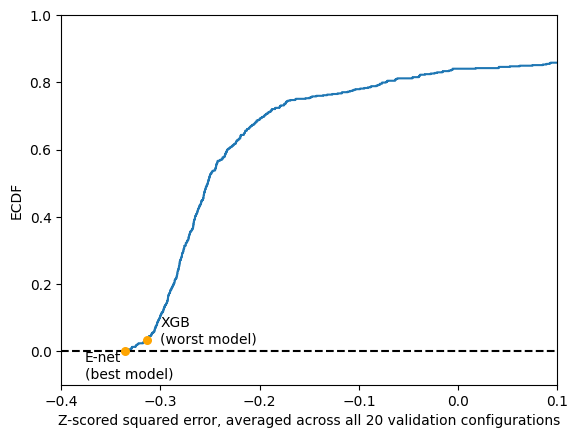

In [62]:
sns.ecdfplot(df_all_predictions.groupby("playerID")["zscore_squared_error"].mean())
plt.xlabel("Z-scored squared error, averaged across all 20 validation configurations")
plt.ylabel("ECDF")
plt.xlim(-0.4, 0.1)
plt.ylim(-0.1, 1)

plt.scatter(x=mean_elastic_zscore, y=(df_all_predictions.groupby("playerID")["zscore_squared_error"].mean().sort_values() <= mean_elastic_zscore).mean(), color="orange", s=30, zorder=1000)
plt.text(x=-0.375998, y=-0.08, s="E-net\n(best model)")

plt.scatter(x=mean_xgb_zscore, y=(df_all_predictions.groupby("playerID")["zscore_squared_error"].mean().sort_values() <= mean_xgb_zscore).mean(), color="orange", s=30, zorder=1000)
plt.text(x=-0.30, y=0.025, s="XGB\n(worst model)")

plt.axhline(0, linestyle="--", color="black")
plt.savefig("../figures/si_individual_forecaster_perf.png", bbox_inches="tight")

# S11.2. Feature importance for OLS, RF, XGB, and MLP

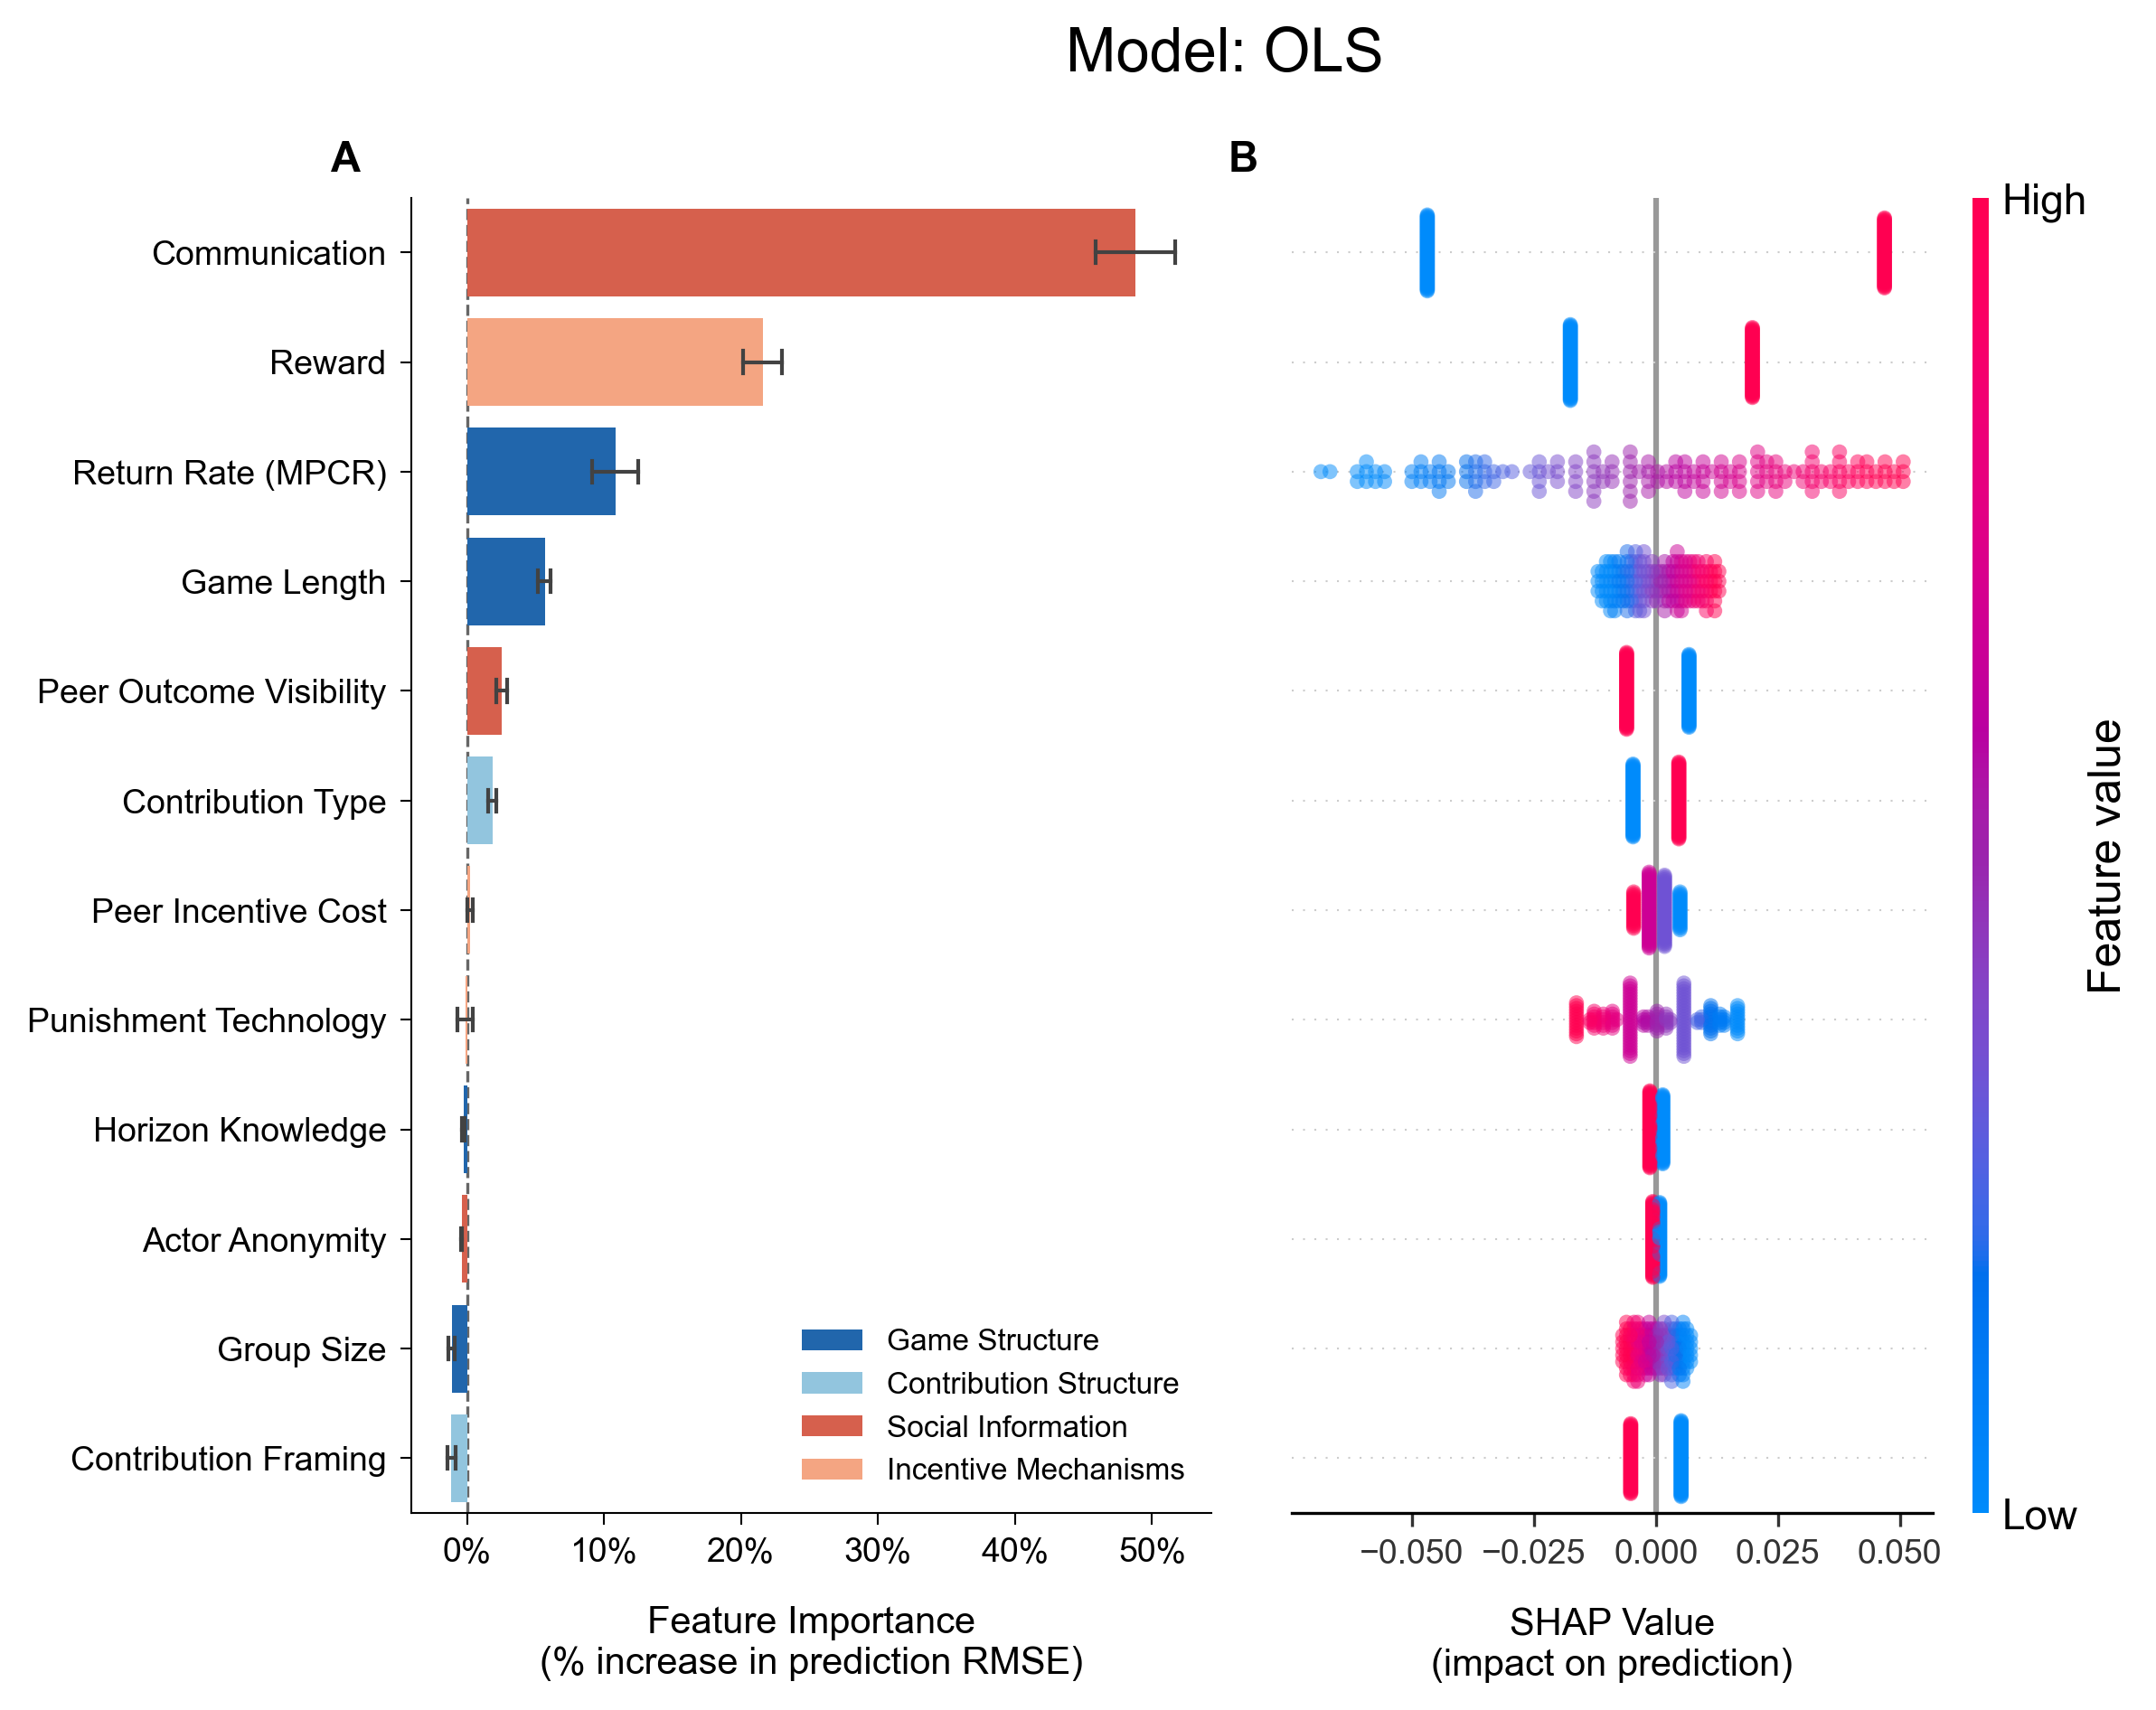

In [32]:
pgg.manuscript_figures.fig4_feature_importance_viz(processed_data_dir="../data/processed_data/", hpo_json_filepath="../data/hpo_model_configs.json", 
                                                   fig_output_path="../figures/si_ols_featimp.png", model_key="ols", model_label="OLS", display_model_label=True)

Permutation explainer: 151it [00:10,  3.39s/it]                                                                                         


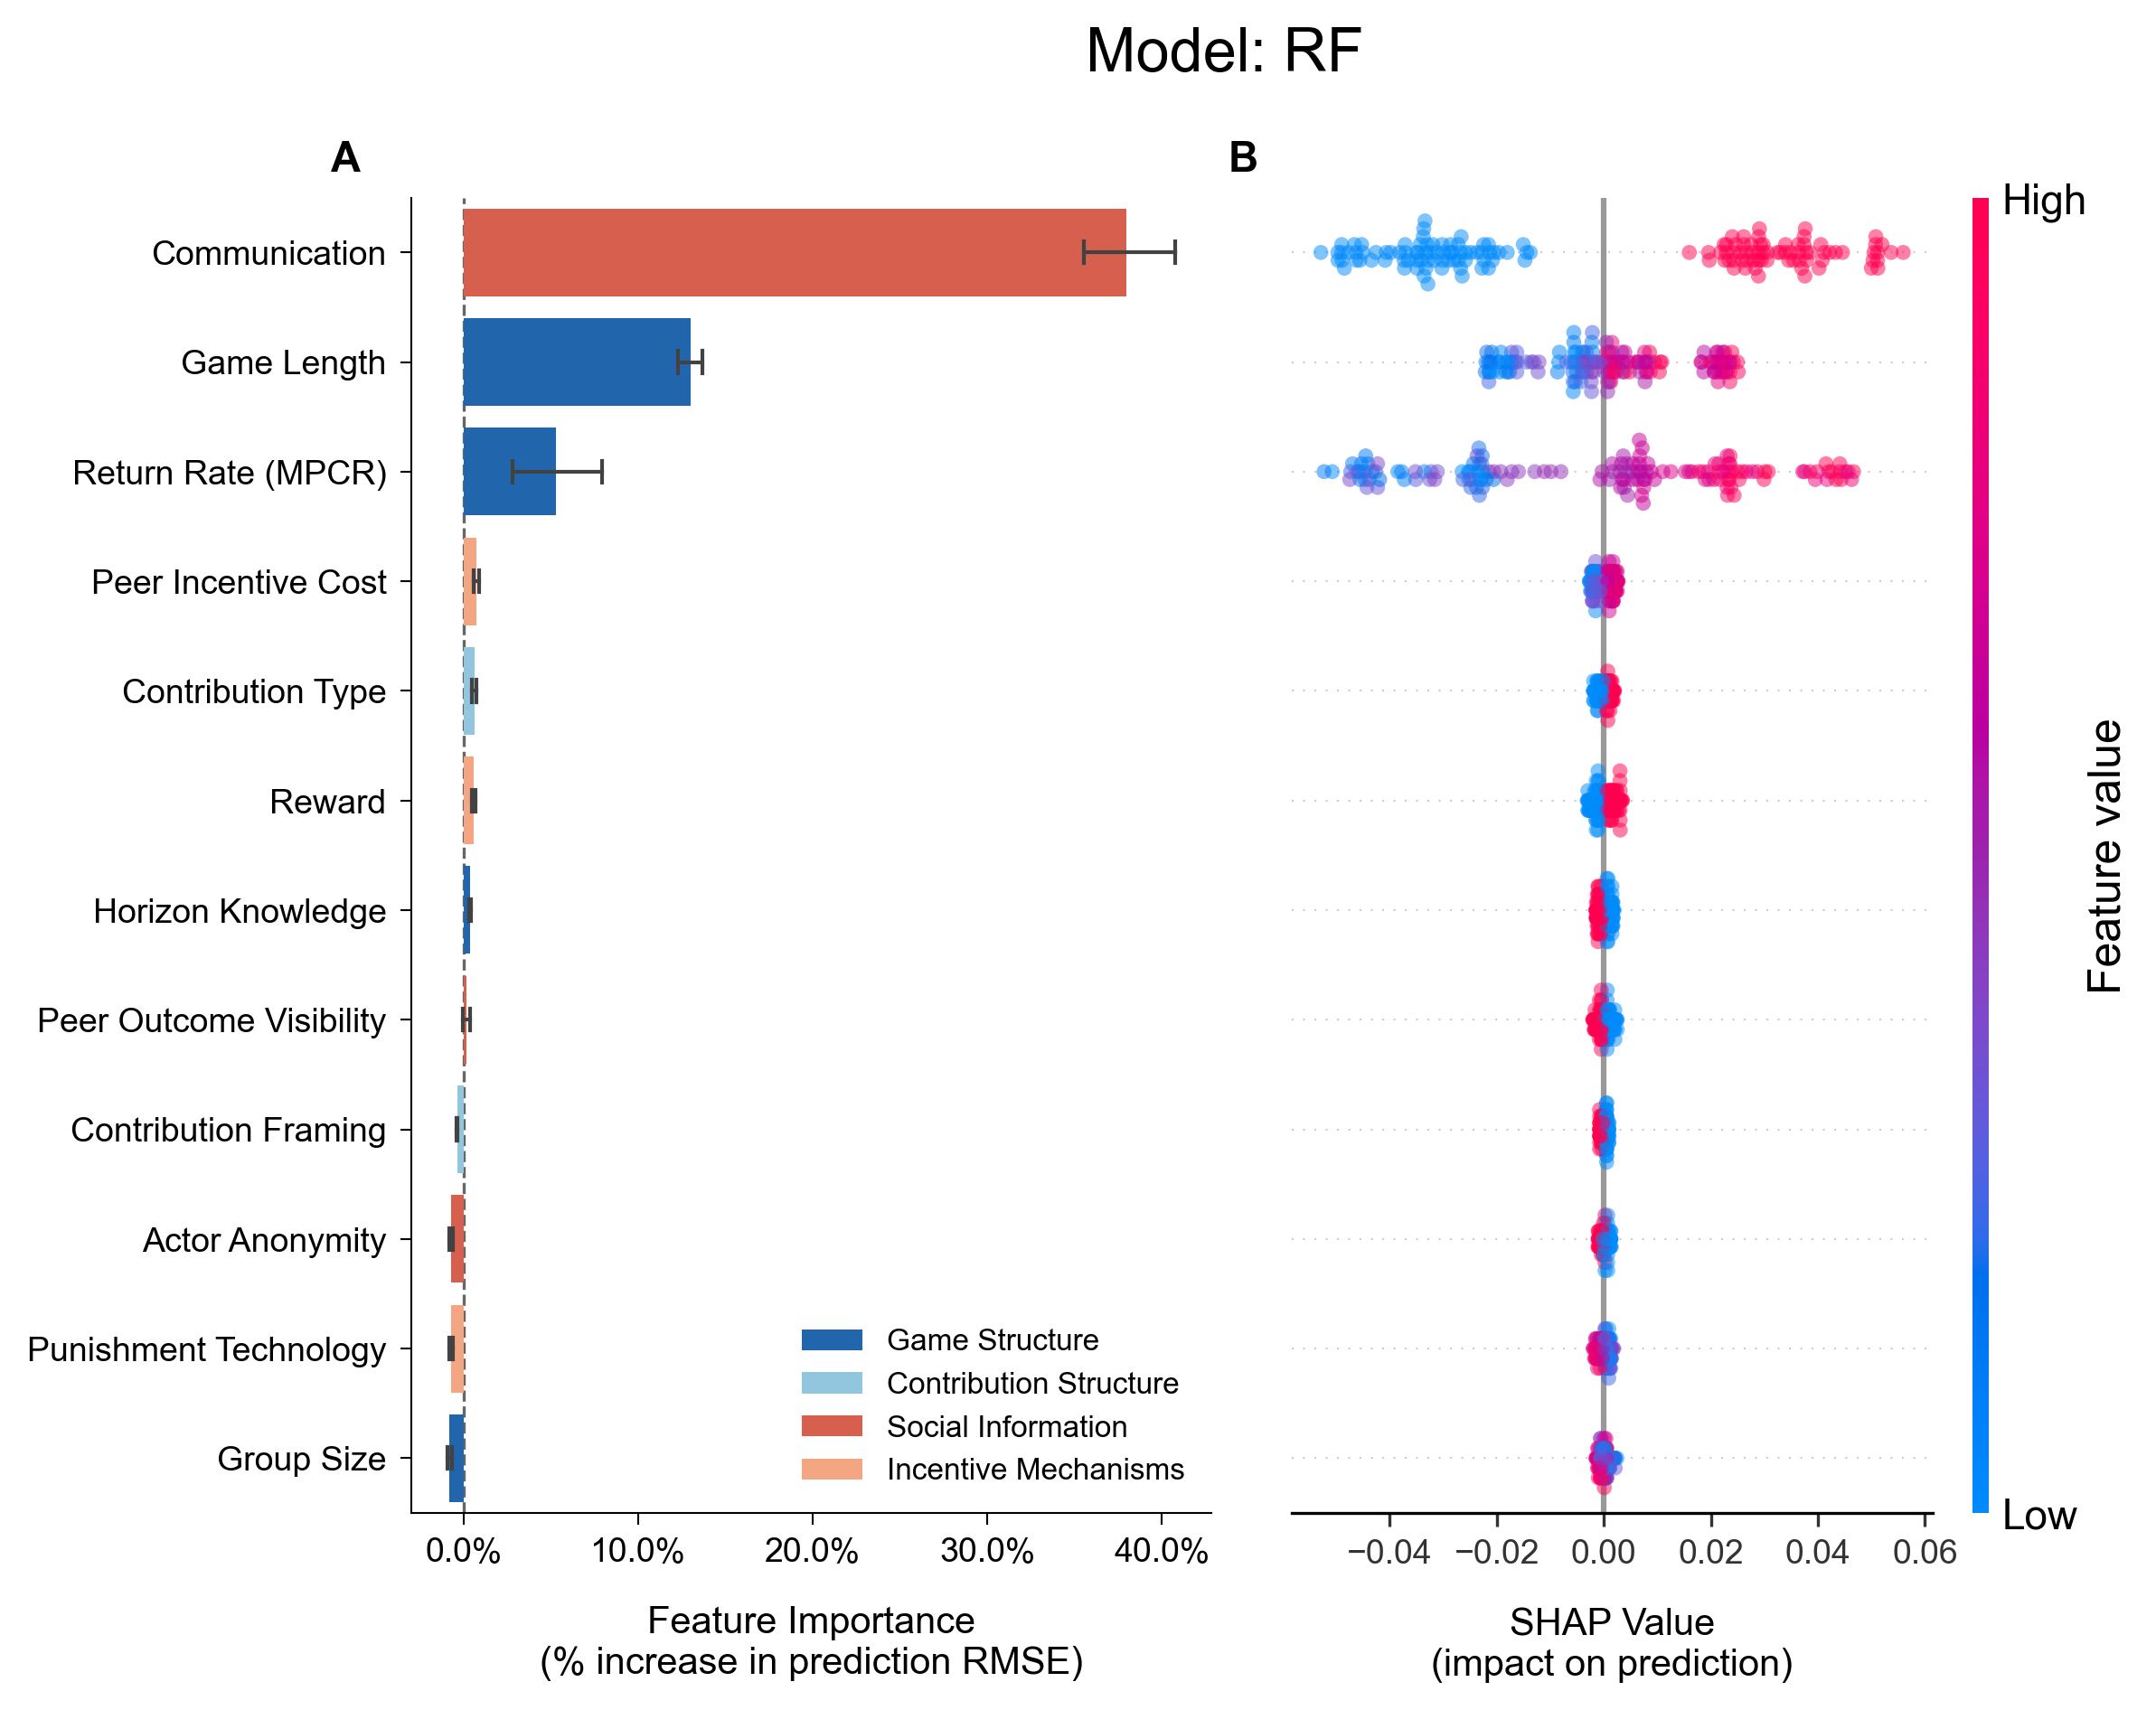

In [33]:
pgg.manuscript_figures.fig4_feature_importance_viz(processed_data_dir="../data/processed_data/", hpo_json_filepath="../data/hpo_model_configs.json", 
                                                   fig_output_path="../figures/si_rf_featimp.png", model_key="rf", model_label="RF", display_model_label=True)

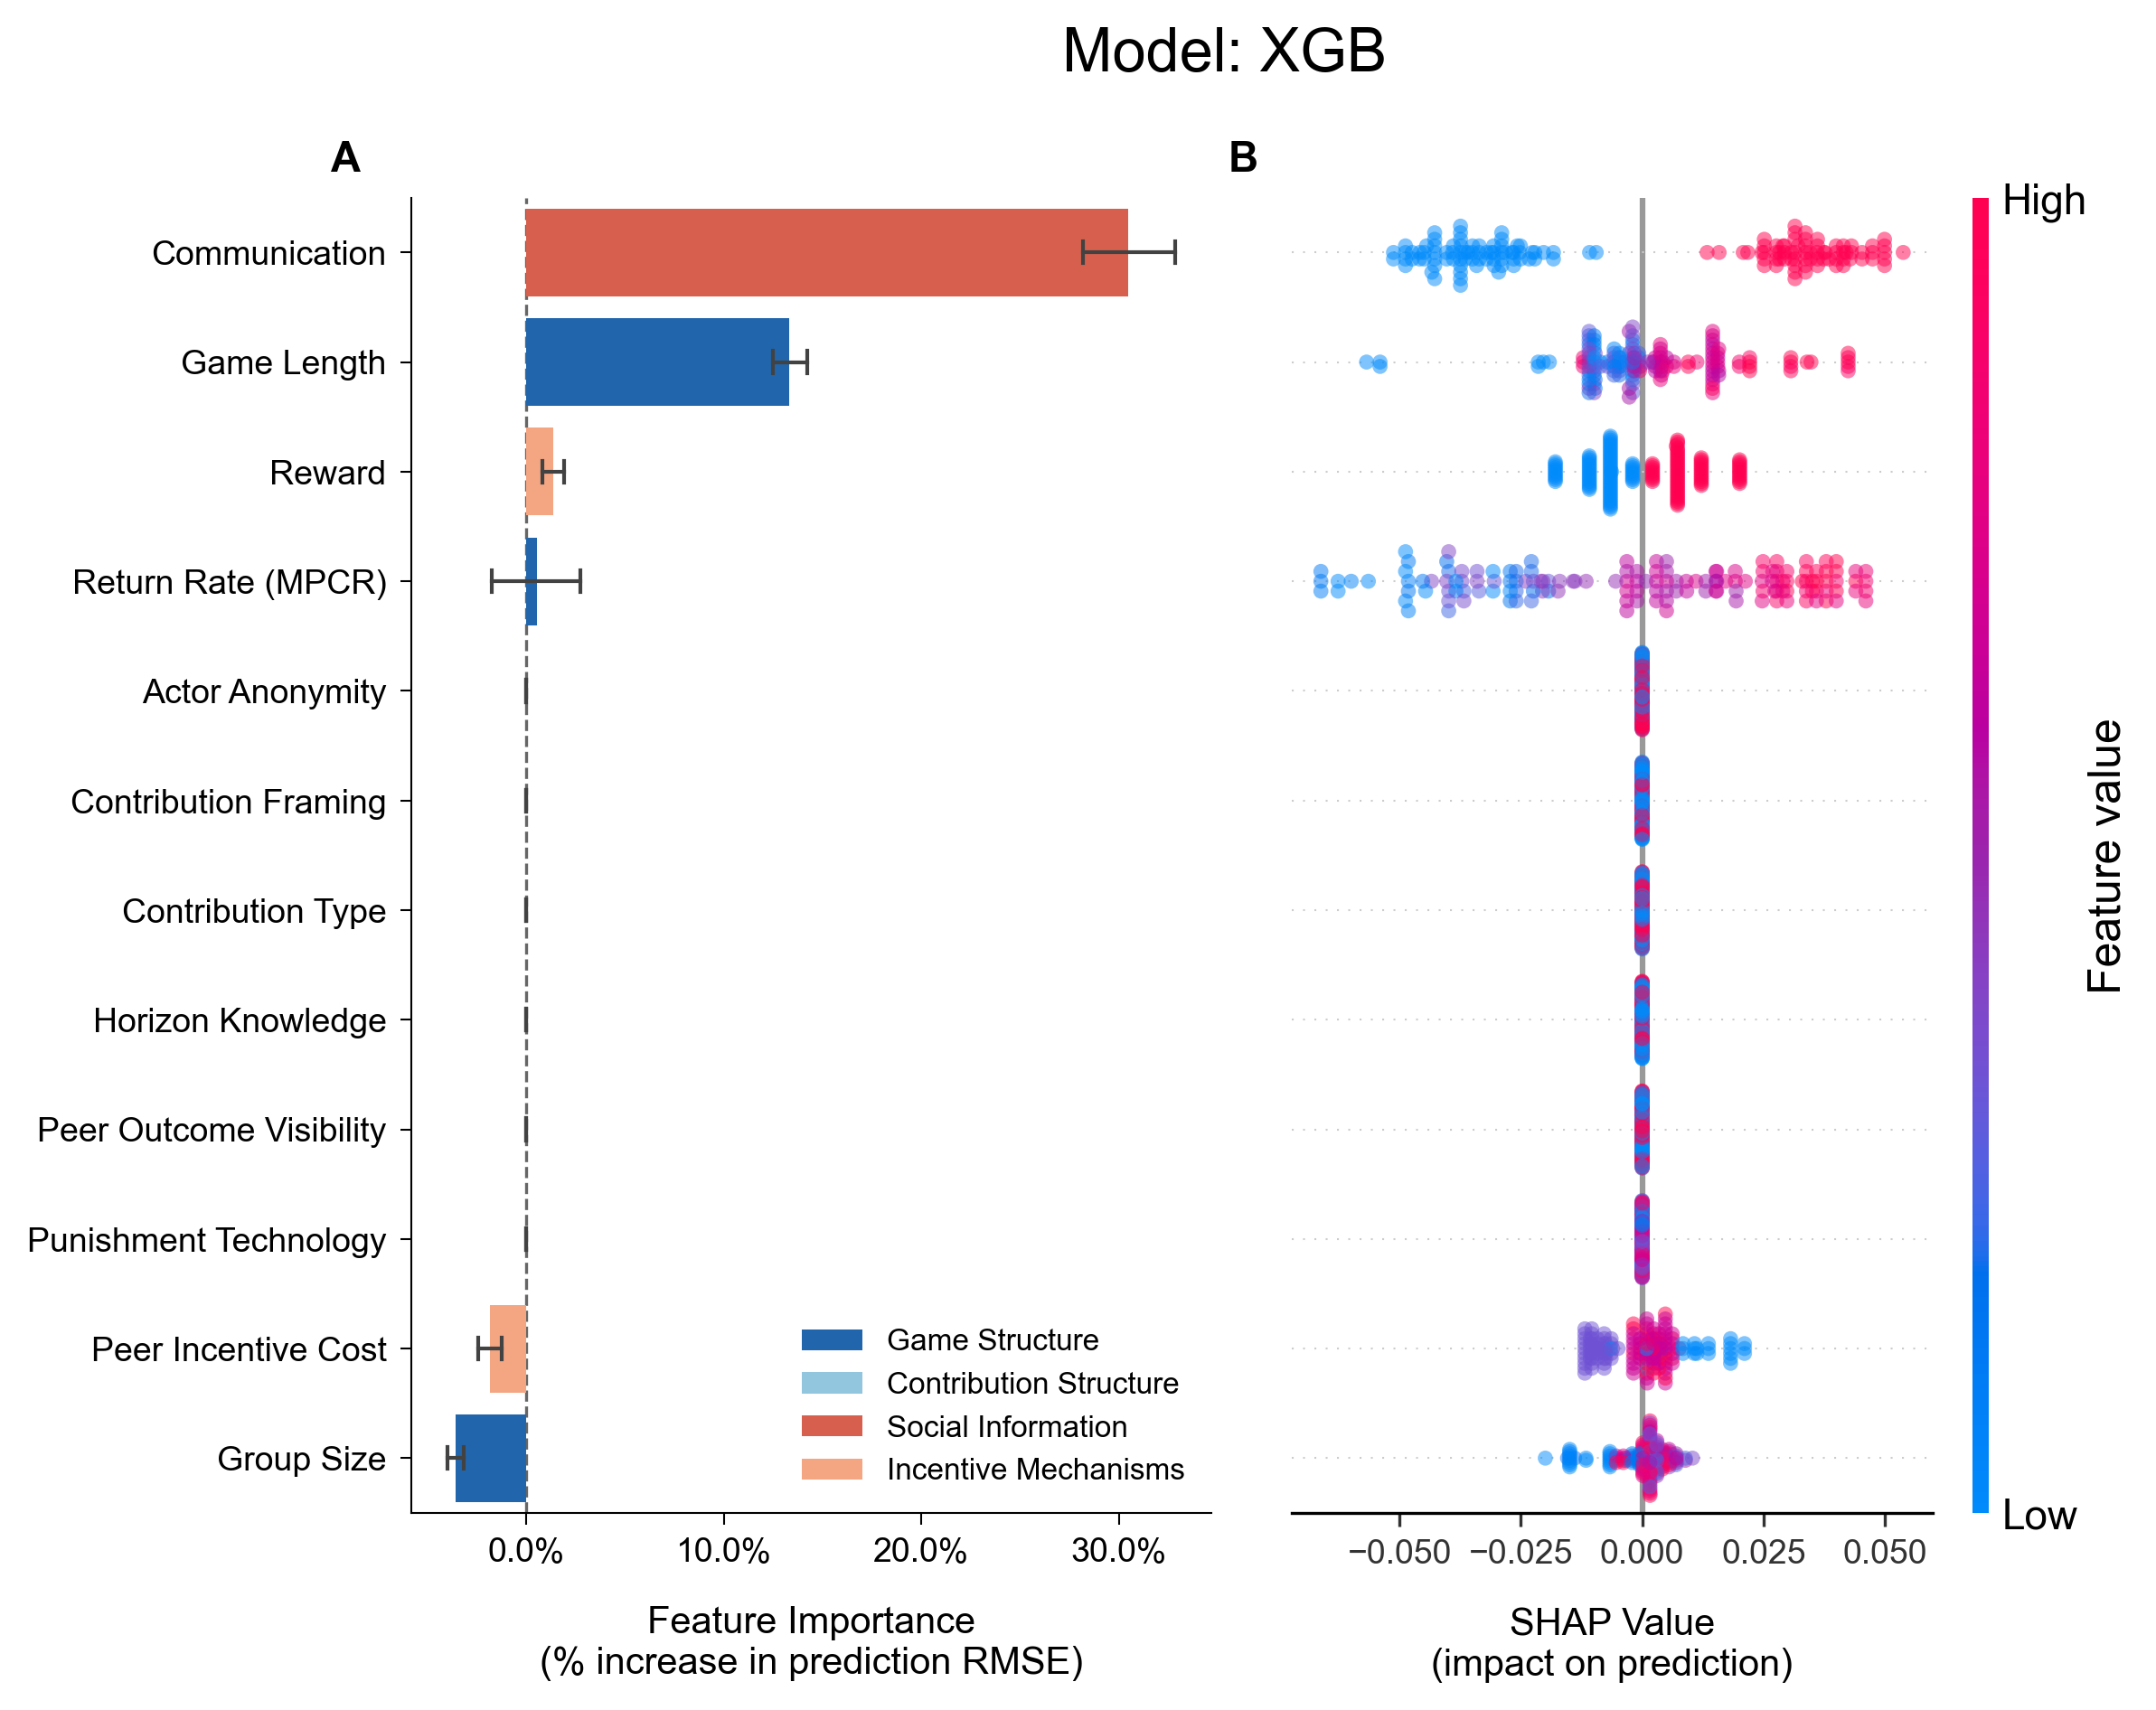

In [34]:
pgg.manuscript_figures.fig4_feature_importance_viz(processed_data_dir="../data/processed_data/", hpo_json_filepath="../data/hpo_model_configs.json", 
                                                   fig_output_path="../figures/si_xgb_featimp.png", model_key="xgb", model_label="XGB", display_model_label=True)

Permutation explainer: 151it [01:38,  1.37it/s]                                                                                         


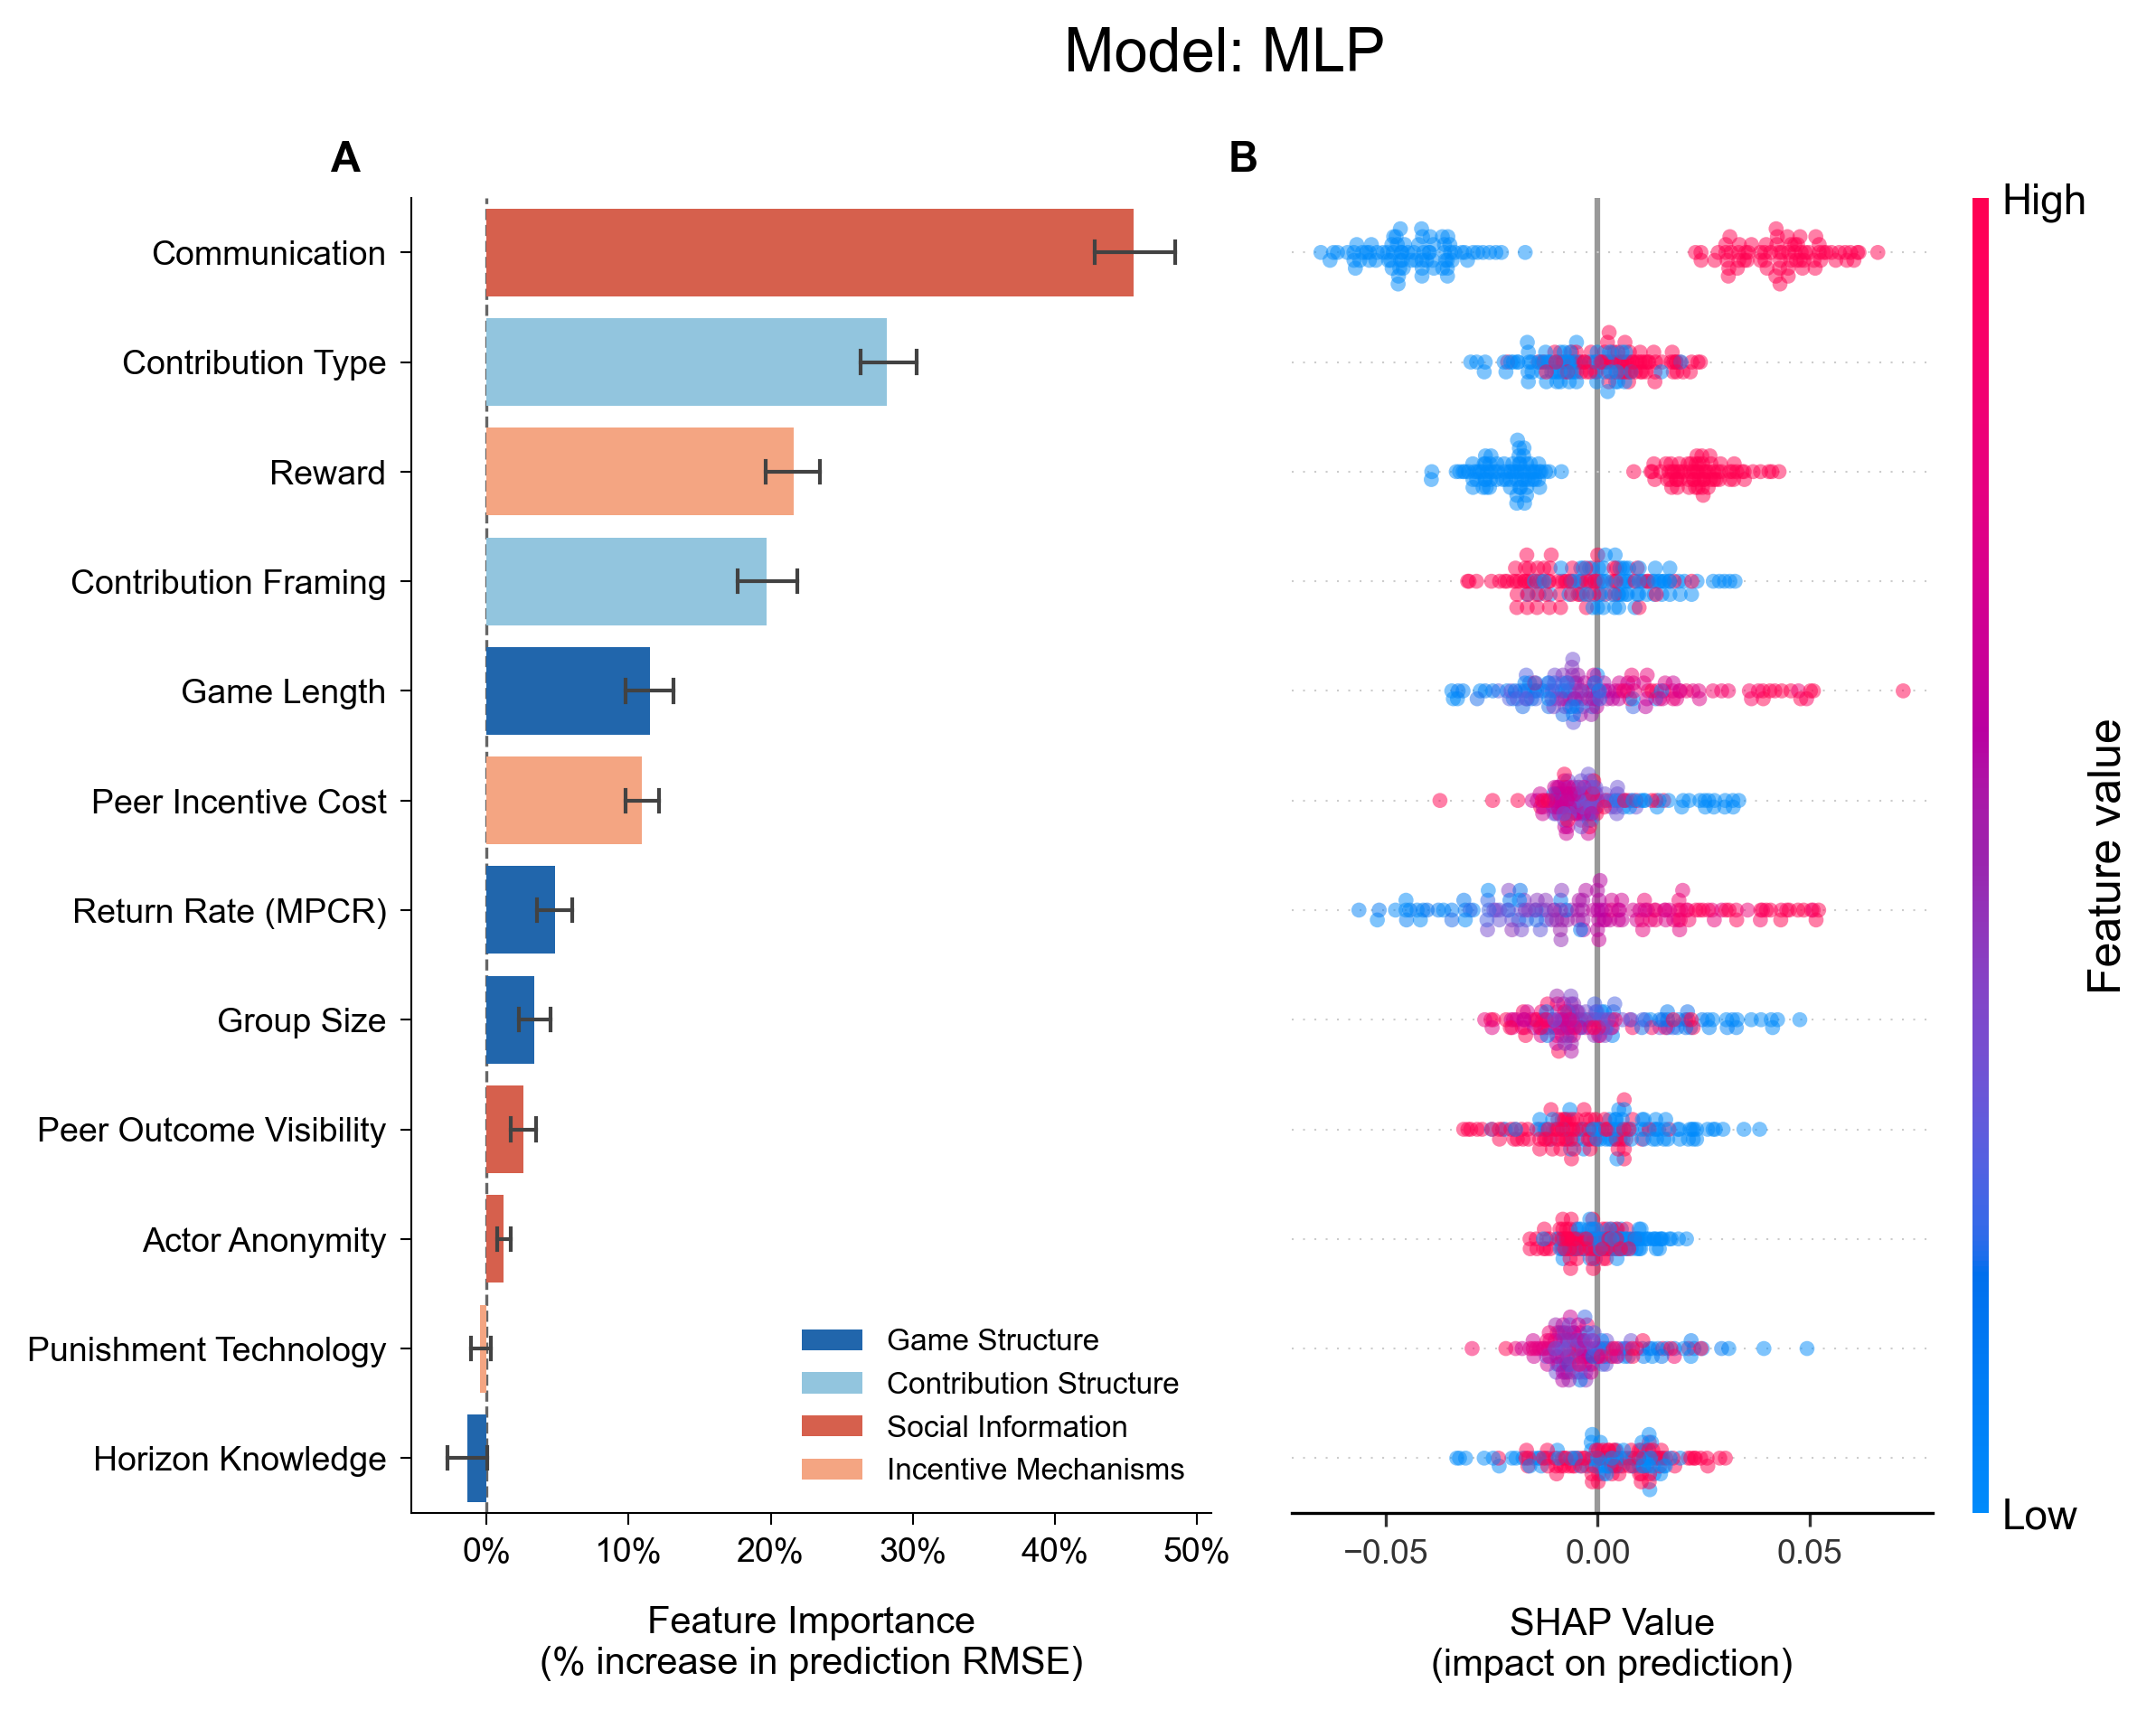

In [35]:
pgg.manuscript_figures.fig4_feature_importance_viz(processed_data_dir="../data/processed_data/", hpo_json_filepath="../data/hpo_model_configs.json", 
                                                   fig_output_path="../figures/si_mlp_featimp.png", model_key="mlp", model_label="MLP", display_model_label=True)